In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Data 

In [2]:
df = pd.read_excel(r"C:\Users\G.Tanuja\Desktop\Clean Data\retail_sales_clean data.xlsx")

In [3]:
df.head()

,order_id,order_date,city,state,category,product_name,quantity,unit_price,discount_percent,payment_mode,customer_age,total_sales,month,revenue
0,10000,2024-02-22,Mumbai,Maharashtra,Electronics,Keyboard,2,1978,5,Net Banking,25.0,3758.20,2,3758.20
1,10001,2024-09-15,Kolkata,West Bengal,Electronics,Headphones,1,1941,5,Net Banking,22.0,1843.95,9,1843.95
2,10002,2024-10-28,Hyderabad,Telangana,Sports,Dumbbells,4,1955,15,Debit Card,22.0,6647.00,10,6647.00
3,10003,2024-04-20,Delhi,Delhi,Sports,Skipping Rope,3,2426,5,Debit Card,25.0,6914.10,4,6914.10
4,10004,2024-05-15,Mumbai,Maharashtra,Home & Kitchen,Mixer,3,2967,20,UPI,NaN,7120.80,5,7120.80


### Understanding Data

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 634
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          634 non-null    int64         
 1   order_date        634 non-null    datetime64[ns]
 2   city              634 non-null    object        
 3   state             634 non-null    object        
 4   category          634 non-null    object        
 5   product_name      634 non-null    object        
 6   quantity          634 non-null    int64         
 7   unit_price        634 non-null    int64         
 8   discount_percent  634 non-null    int64         
 9   payment_mode      634 non-null    object        
 10  customer_age      560 non-null    float64       
 11  total_sales       634 non-null    float64       
 12  month             634 non-null    int64         
 13  revenue           634 non-null    float64       
dtypes: d

In [5]:
df.describe()

,order_id,order_date,quantity,unit_price,discount_percent,customer_age,total_sales,month,revenue
count,634.000000,634,634.000000,634.000000,634.000000,560.000000,634.000000,634.000000,634.000000
mean,10323.671924,2024-07-01 05:47:30.473186048,2.982650,2657.914826,9.960568,31.662500,7174.105994,6.515773,7174.105994
min,10000.000000,2024-01-01 00:00:00,1.000000,186.000000,0.000000,22.000000,181.050000,1.000000,181.050000
25%,10160.250000,2024-03-30 00:00:00,2.000000,1441.500000,5.000000,25.000000,2725.825000,3.000000,2725.825000
50%,10322.500000,2024-07-03 00:00:00,3.000000,2707.500000,10.000000,30.000000,5827.100000,7.000000,5827.100000
75%,10487.750000,2024-10-02 00:00:00,4.000000,3841.500000,15.000000,40.000000,10401.000000,10.000000,10401.000000
max,10649.000000,2024-12-31 00:00:00,5.000000,4985.000000,20.000000,45.000000,24215.000000,12.000000,24215.000000
std,188.193657,NaN,1.381901,1391.423444,7.006431,7.576351,5447.349190,3.463267,5447.349190


### Check missing values

In [6]:
df.isnull().sum()

order_id             0
order_date           0
city                 0
state                0
category             0
product_name         0
quantity             0
unit_price           0
discount_percent     0
payment_mode         0
customer_age        74
total_sales          0
month                0
revenue              0
dtype: int64

### Check duplicates

In [7]:
df.drop_duplicates(inplace=True)

### Total orders

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [9]:
df['month'] = df['order_date'].dt.month

In [20]:
total_orders = df["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 634


### Total Revenue

In [10]:
df['revenue'] = df['quantity'] * df['unit_price']

In [11]:
df['revenue'] = df['revenue'] - (df['revenue'] * df['discount_percent']/100)

In [16]:
total_revenue = df["revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 4548383.199999999


In [13]:
sales_by_category = df.groupby('category')['revenue'].sum()

In [14]:
sales_by_city = df.groupby('city')['revenue'].sum()

In [15]:
sales_by_month = df.groupby('month')['revenue'].sum()

### Total Quantity

In [17]:
total_quantity = df["quantity"].sum()
print("Total Quantity:", total_quantity)

Total Quantity: 1891


### Average Order Value

In [22]:
avg = total_revenue / total_orders
print("Average Order Value:", round(avg, 2))

Average Order Value: 7174.11


### Monthly Revenue Trend

In [23]:
monthly_revenue = (
    df.groupby("month")["revenue"]
    .sum()
    .sort_index()
)

print(monthly_revenue)

month
1     424627.20
2     326701.45
3     422385.10
4     277349.45
5     354822.55
6     376867.25
7     425494.50
8     380194.80
9     320329.40
10    444522.50
11    339467.30
12    455621.70
Name: revenue, dtype: float64


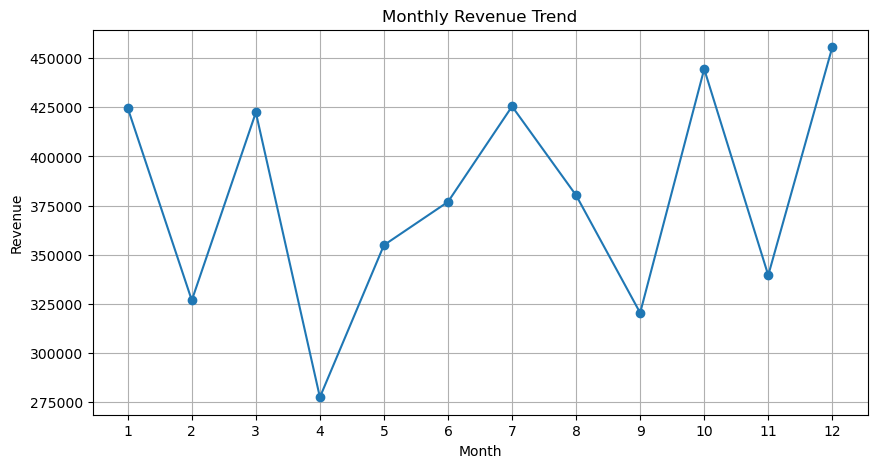

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

### Revenue by Category

In [26]:
category_revenue = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Sports            914389.00
Clothing          753535.85
Home & Kitchen    753354.50
Electronics       718641.80
Grocery           709690.25
Beauty            698771.80
Name: revenue, dtype: float64


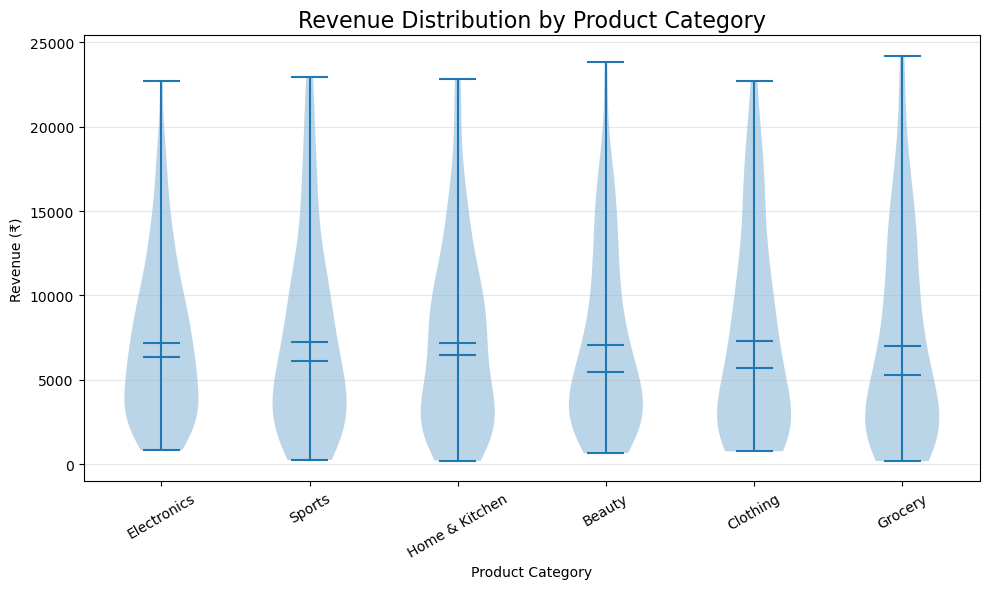

In [53]:
plt.figure(figsize=(10, 6))

# Create violin plot using individual transaction revenues
categories = df["category"].dropna().unique()

data = [
    df[df["category"] == category]["revenue"].dropna()
    for category in categories
]

plt.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

plt.title("Revenue Distribution by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Revenue (₹)")

plt.xticks(
    range(1, len(categories) + 1),
    categories,
    rotation=30
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Revenue by city

In [28]:
city_revenue = (
    df.groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(city_revenue)
        

city
Bangalore    659878.70
Chennai      615328.55
Delhi        582051.20
Kolkata      579955.45
Hyderabad    551029.70
Pune         550736.00
Ahmedabad    529118.55
Mumbai       480285.05
Name: revenue, dtype: float64


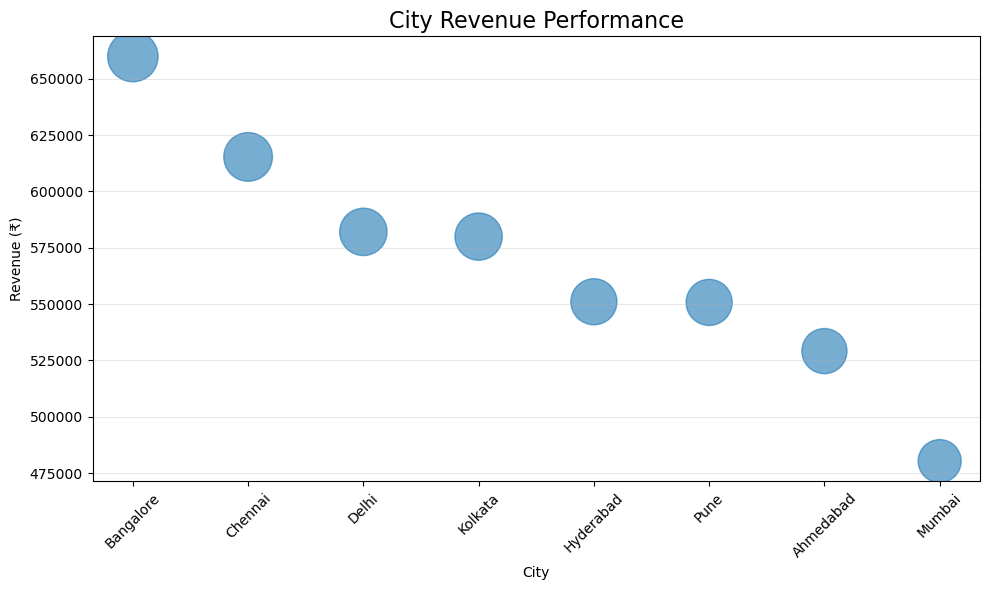

In [52]:
plt.figure(figsize=(10, 6))

city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)

plt.scatter(
    city_revenue.index,
    city_revenue.values,
    s=city_revenue.values / 500,
    alpha=0.6
)

plt.title("City Revenue Performance", fontsize=16)
plt.xlabel("City")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Top 10 Products

In [30]:
top_products = (
    df.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_name
Skipping Rope    235228.95
Jacket           221261.05
Lunch Box        218757.00
Shampoo          213523.50
Dumbbells        211840.55
Cooking Oil      184106.90
Tea Powder       180087.75
Yoga Mat         177959.85
Jeans            177745.35
Face Wash        166744.30
Name: revenue, dtype: float64


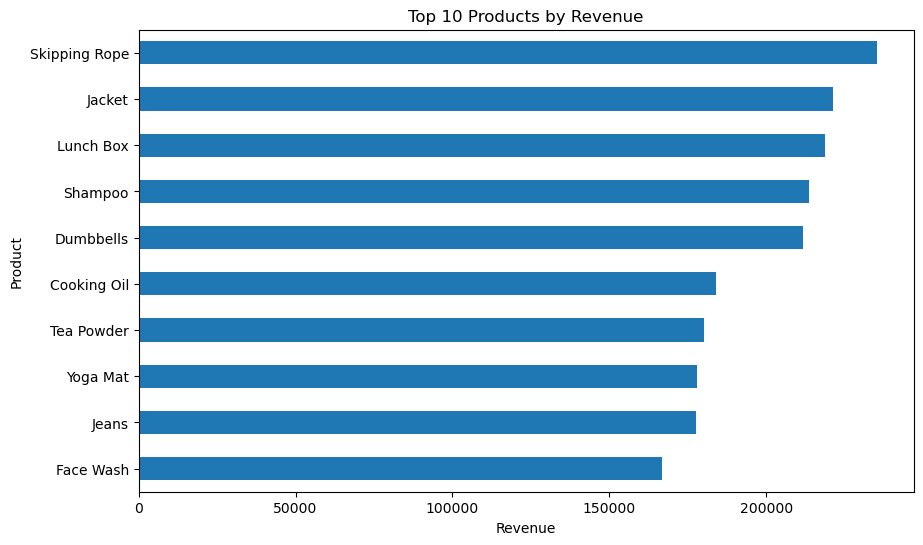

In [31]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

### Quantity sold by category

In [32]:
category_quantity = (
    df.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity)

category
Sports            357
Home & Kitchen    328
Clothing          310
Grocery           302
Electronics       300
Beauty            294
Name: quantity, dtype: int64


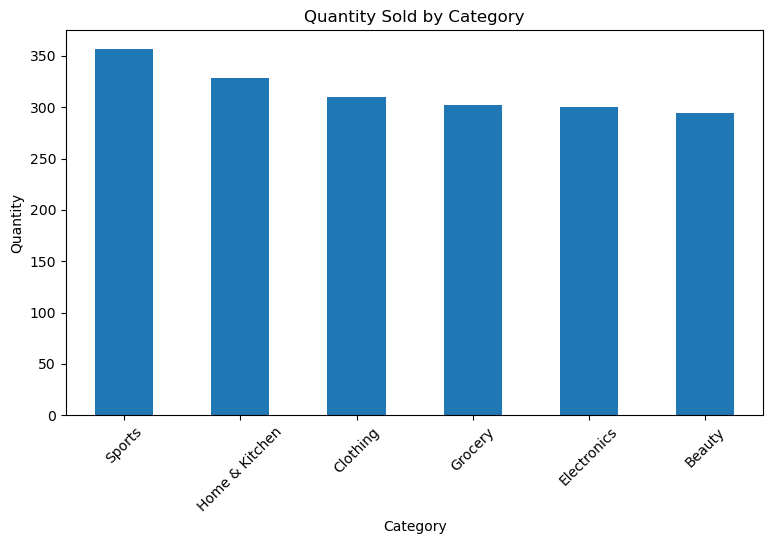

In [33]:
plt.figure(figsize=(9,5))

category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.show()

### Revenue by payment mode

In [34]:
payment_revenue = (
    df.groupby("payment_mode")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_revenue)

payment_mode
Debit Card     1091879.30
Net Banking     909475.35
Cash            890176.75
Credit Card     850977.35
UPI             805874.45
Name: revenue, dtype: float64


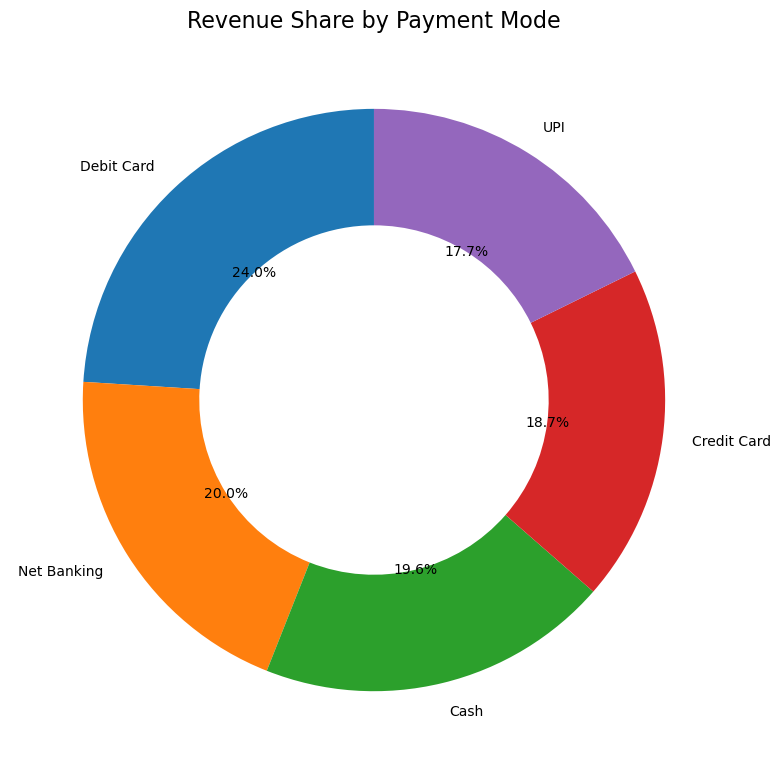

In [48]:
plt.figure(figsize=(8, 8))

plt.pie(
    payment_revenue,
    labels=payment_revenue.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Revenue Share by Payment Mode", fontsize=16)

plt.tight_layout()
plt.show()

### Customer Age Analysis

In [36]:
bins = [17, 25, 35, 45, 55, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["age_group"] = pd.cut(
    df["customer_age"],
    bins=bins,
    labels=labels
)

In [37]:
age_revenue = (
    df.groupby("age_group", observed=True)["revenue"]
    .sum()
)

print(age_revenue)

age_group
18-25    1280524.70
26-35    1690647.30
36-45     994792.45
Name: revenue, dtype: float64


C:\Users\G.Tanuja\AppData\Local\Temp\ipykernel_21580\1681142798.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_category_revenue = pd.pivot_table(


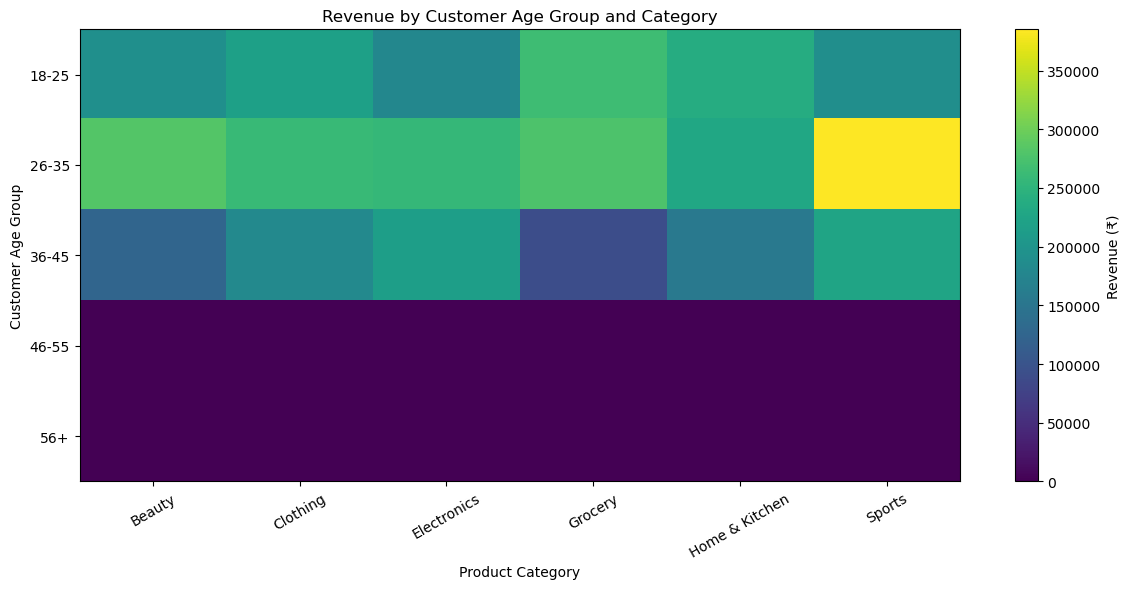

In [51]:
age_category_revenue = pd.pivot_table(
    df,
    values="revenue",
    index="age_group",
    columns="category",
    aggfunc="sum"
)

plt.figure(figsize=(12, 6))

plt.imshow(
    age_category_revenue,
    aspect="auto"
)

plt.colorbar(label="Revenue (₹)")

plt.xticks(
    range(len(age_category_revenue.columns)),
    age_category_revenue.columns,
    rotation=30
)

plt.yticks(
    range(len(age_category_revenue.index)),
    age_category_revenue.index
)

plt.title("Revenue by Customer Age Group and Category")
plt.xlabel("Product Category")
plt.ylabel("Customer Age Group")

plt.tight_layout()
plt.show()

### Discount vs Revenue

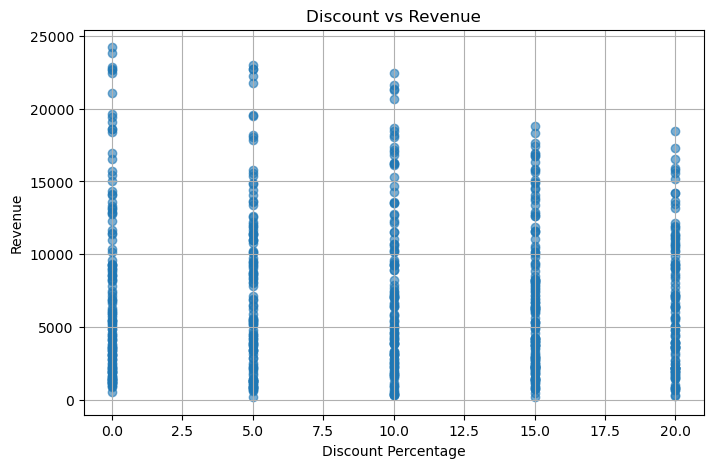

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["discount_percent"],
    df["revenue"],
    alpha=0.6
)

plt.title("Discount vs Revenue")
plt.xlabel("Discount Percentage")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Quantity vs Revenue

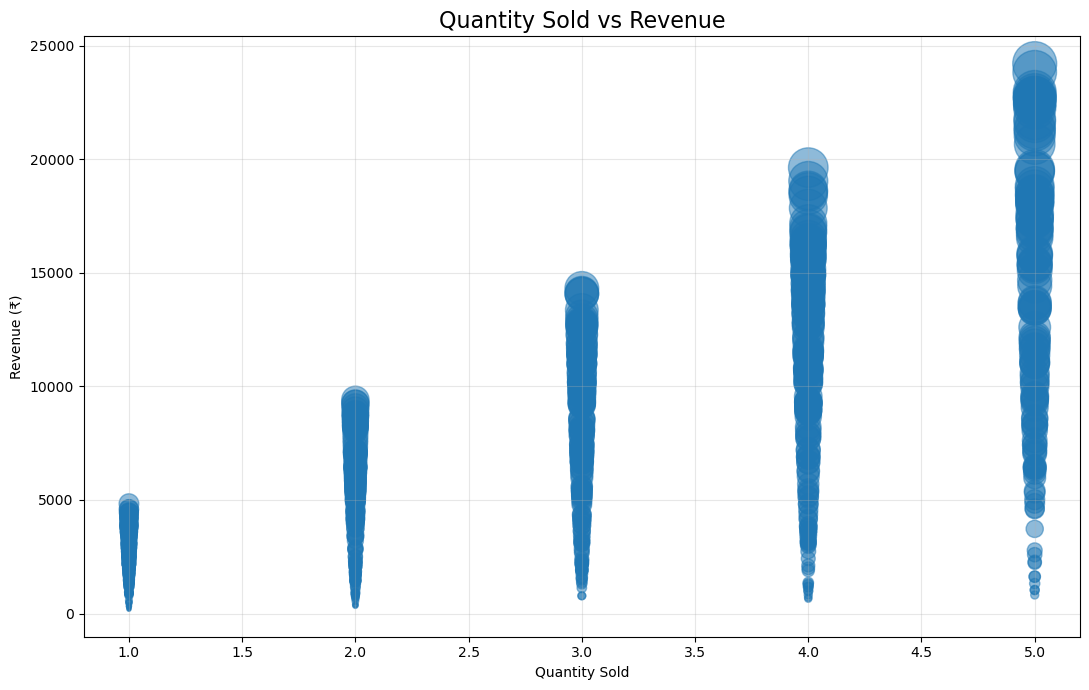

In [47]:
plt.figure(figsize=(11, 7))

bubble_size = df["revenue"] / df["revenue"].max() * 1000

plt.scatter(
    df["quantity"],
    df["revenue"],
    s=bubble_size,
    alpha=0.5
)

plt.title("Quantity Sold vs Revenue", fontsize=16)
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue (₹)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### City x payment Mode

In [41]:
city_payment = pd.pivot_table(
    df,
    values="revenue",
    index="city",
    columns="payment_mode",
    aggfunc="sum"
)

print(city_payment)

payment_mode       Cash  Credit Card  Debit Card  Net Banking        UPI
city                                                                    
Ahmedabad     115056.15     49847.25   179386.30     98868.40   85960.45
Bangalore      90374.80    131857.85   172734.60     75869.65  189041.80
Chennai       183259.20    133050.35   118822.15    132184.35   48012.50
Delhi          79706.50     78121.70   182982.10    136589.90  104651.00
Hyderabad     109456.05    111367.95   111724.45    112553.85  105927.40
Kolkata       122842.45    148653.55    78066.50    124967.05  105425.90
Mumbai        109599.45     72530.85   135700.95     93021.00   69432.80
Pune           79882.15    125547.85   112462.25    135421.15   97422.60


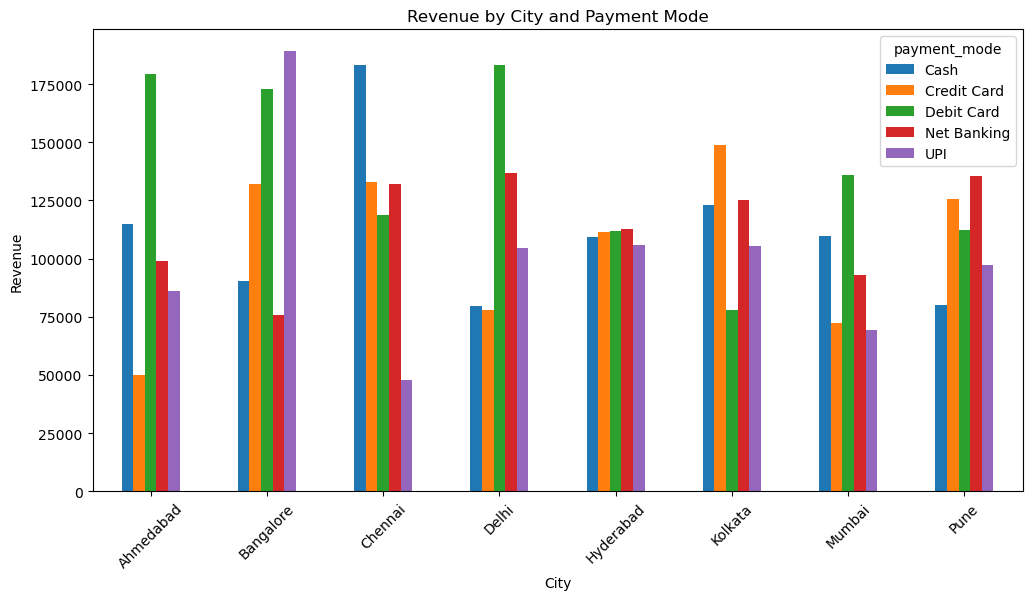

In [42]:
city_payment.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Revenue by City and Payment Mode")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### category x Payment Mode

In [43]:
category_payment = pd.pivot_table(
    df,
    values="revenue",
    index="category",
    columns="payment_mode",
    aggfunc="sum"
)

category_payment

payment_mode,Cash,Credit Card,Debit Card,Net Banking,UPI
category,,,,,
Beauty,147336.65,108706.10,127138.80,153211.75,162378.50
Clothing,136705.50,143863.90,188199.80,155491.40,129275.25
Electronics,128429.30,141196.65,106891.45,227334.05,114790.35
Grocery,93122.15,148584.25,265376.90,90200.30,112406.65
Home & Kitchen,164420.80,121164.00,168350.65,163306.30,136112.75
Sports,220162.35,187462.45,235921.70,119931.55,150910.95


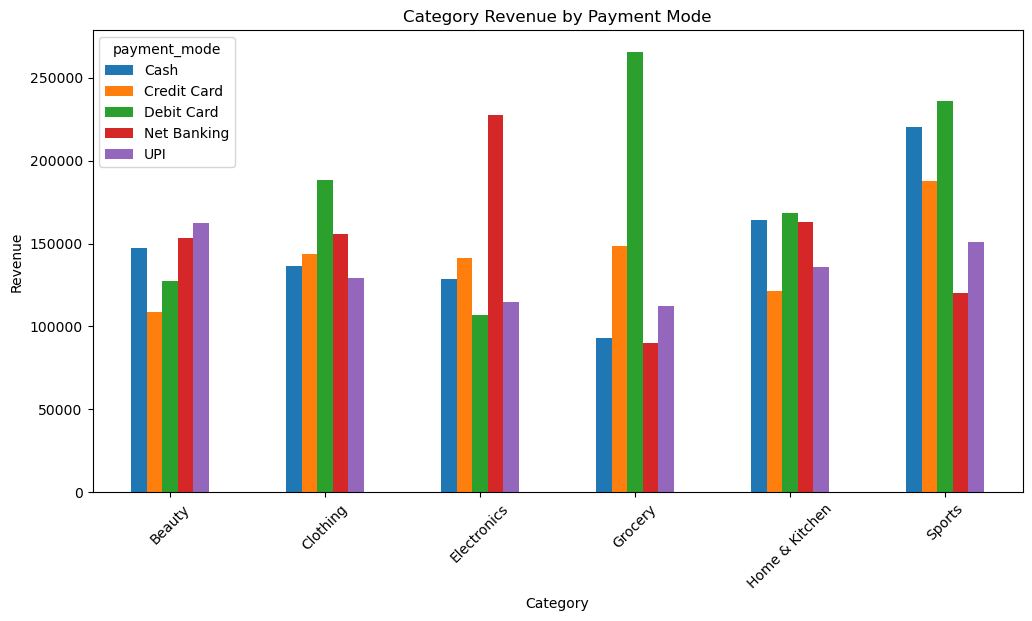

In [44]:
category_payment.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Category Revenue by Payment Mode")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Monthly Revenue + Category

In [45]:
monthly_category = pd.pivot_table(
    df,
    values="revenue",
    index="month",
    columns="category",
    aggfunc="sum"
)

monthly_category

category,Beauty,Clothing,Electronics,Grocery,Home & Kitchen,Sports
month,,,,,,
1,53580.15,106330.90,77131.80,63035.75,59009.40,65539.20
2,35171.50,37958.80,55843.35,27192.45,61502.60,109032.75
3,56806.05,70717.05,86682.30,66260.80,37310.85,104608.05
4,63540.70,45272.65,50628.65,41425.35,32871.50,43610.60
5,31067.30,109537.00,31365.20,64021.10,63206.00,55625.95
6,52249.20,45710.30,33725.75,61434.70,32954.40,150792.90
7,99558.25,67312.60,62793.45,52217.45,92797.05,50815.70
8,66774.30,76202.05,31011.70,63943.35,91190.05,51073.35
9,71713.10,66738.60,19685.65,31928.60,27699.65,102563.80


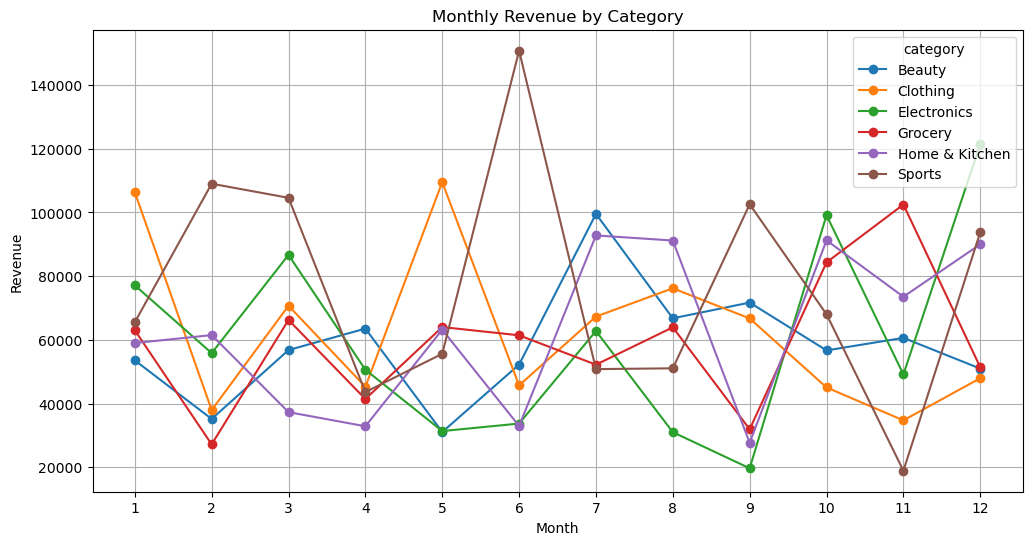

In [46]:
monthly_category.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(1,13))

plt.grid(True)

plt.show()